In [10]:
from pprint import pprint
import m2aia as m2
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

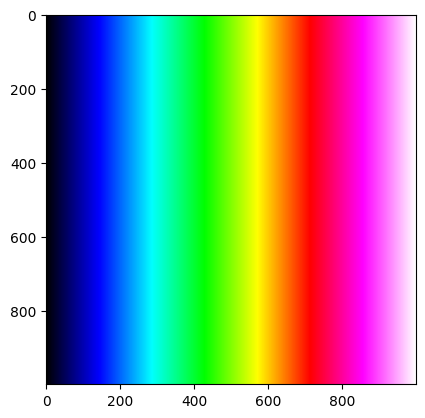

In [4]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

colors = [(0, 0, 0), (0, 0, 1), (0, 1, 1), (0, 1, 0),(1, 1, 0), (1, 0, 0),(1, 0, 1),(1, 1, 1)] 
cm = LinearSegmentedColormap.from_list(
        "Custom", colors, N=1000)
mat = np.indices((1000,1000))[1]
plt.imshow(mat, cmap=cm)
plt.show()

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

def showimg(image, cmap=None, 
            vmin=None, vmax=None,
            title=None, size=(10,10), spacing=None, fig=None, subplot_pos=(1,1,1)):
    sns.set_theme(style="ticks")
    
    if fig is None:
        fig = plt.figure(figsize = size) # create a 5 x 5 figure 
    
    ax = fig.add_subplot(subplot_pos[0],subplot_pos[1],subplot_pos[2])

    ax.tick_params(
        which='both',
        bottom=False,
        left=False,
        labelleft=False,
        labelbottom=False)
    x = [10,60]
    y = [10,10]

    if spacing is not None:
        ax.plot(x, y, color="white", linewidth=3)
        ax.text(x[0], y[0]+7, f"{int(spacing[0]*(x[1]-x[0])* 1000)} μm", color="white",size=14)
        
    if title:
        ax.text(x[0], y[0]-3, title, color="white", size=14)
        
    im = ax.imshow(image, interpolation='none', cmap=cmap, vmin=vmin, vmax=vmax)
    fig.colorbar(im)

    return fig, ax 

In [2]:
import subprocess
system = subprocess.check_output(["hostname", "-s"]).decode("utf-8").strip()
BASE_PATH_ = Path()
if "bun" in system:
    BASE_PATH_ = Path("/scratch/project_mnt/S0010/Xiao/Q1851/Xiao/")
elif "imb-quan-gpu" in system:
    BASE_PATH_ = Path("/home/uqxtan9/Q1851/Xiao/")


BASE_PATH = BASE_PATH_ / "Working_project/MB"
DATA_PATH = BASE_PATH / "Xenium_Brain"
XENIUM_RAW_PATH = DATA_PATH / "Xenium_RAW"
MALDI_RAW_PATH = DATA_PATH / "MALDI_RAW/imzml_file"
PROCESSED = BASE_PATH / "PROCESSED"
PROCESSED.mkdir(exist_ok=True, parents=True)
OUT_PATH = BASE_PATH / "PLOTS" / "Xenium"
OUT_PATH.mkdir(exist_ok=True, parents=True)
QC_PATH = OUT_PATH / "QC"
QC_PATH.mkdir(exist_ok=True, parents=True)
CLS_PATH = OUT_PATH / "CLUSTERING"
CLS_PATH.mkdir(exist_ok=True, parents=True)
MALDI_PATH = OUT_PATH / "MALDI"
MALDI_PATH.mkdir(exist_ok=True, parents=True)

In [3]:
Sample = ["Ctrl_1", "Ctrl_2", "Treated_1", "Treated_2"]
Sample_ = ["control 1", "control 2", "treated 1", "treated 2"]

[117.542] [imzML]: /home/uqxtan9/Q1851/Xiao/Working_project/MB/Xenium_Brain/MALDI_RAW/imzml_file/dhb-tissue region control 1.imzML
	[pixel size (mm)]: 0.020000x0.020000x0.010000
	[image dimension]: 310x356x1
	[num spectra]: 84027
	[spec. type]: ProcessedCentroid
	[mass range]: 160.713978 to 2999.027599 with #1500 measurements
	[normalization]: RMS
[124.407] [imzML]: /home/uqxtan9/Q1851/Xiao/Working_project/MB/Xenium_Brain/MALDI_RAW/imzml_file/dhb-tissue region control 2.imzML
	[pixel size (mm)]: 0.020000x0.020000x0.010000
	[image dimension]: 255x427x1
	[num spectra]: 71722
	[spec. type]: ProcessedCentroid
	[mass range]: 160.855288 to 2999.028214 with #1500 measurements
	[normalization]: RMS
[134.110] [imzML]: /home/uqxtan9/Q1851/Xiao/Working_project/MB/Xenium_Brain/MALDI_RAW/imzml_file/dhb-tissue region treated 1.imzML
	[pixel size (mm)]: 0.020000x0.020000x0.010000
	[image dimension]: 325x507x1
	[num spectra]: 116598
	[spec. type]: ProcessedCentroid
	[mass range]: 160.809851 to 2999.02

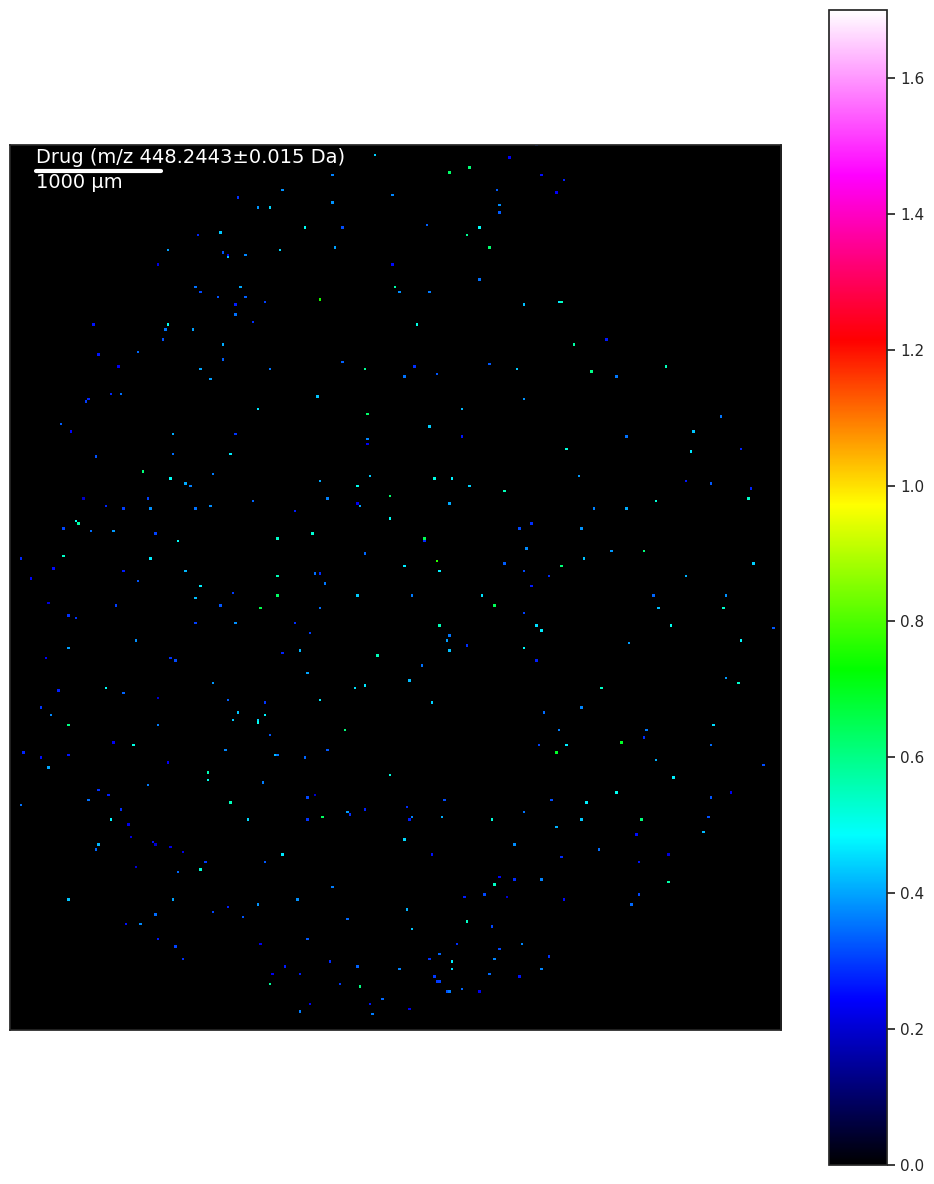

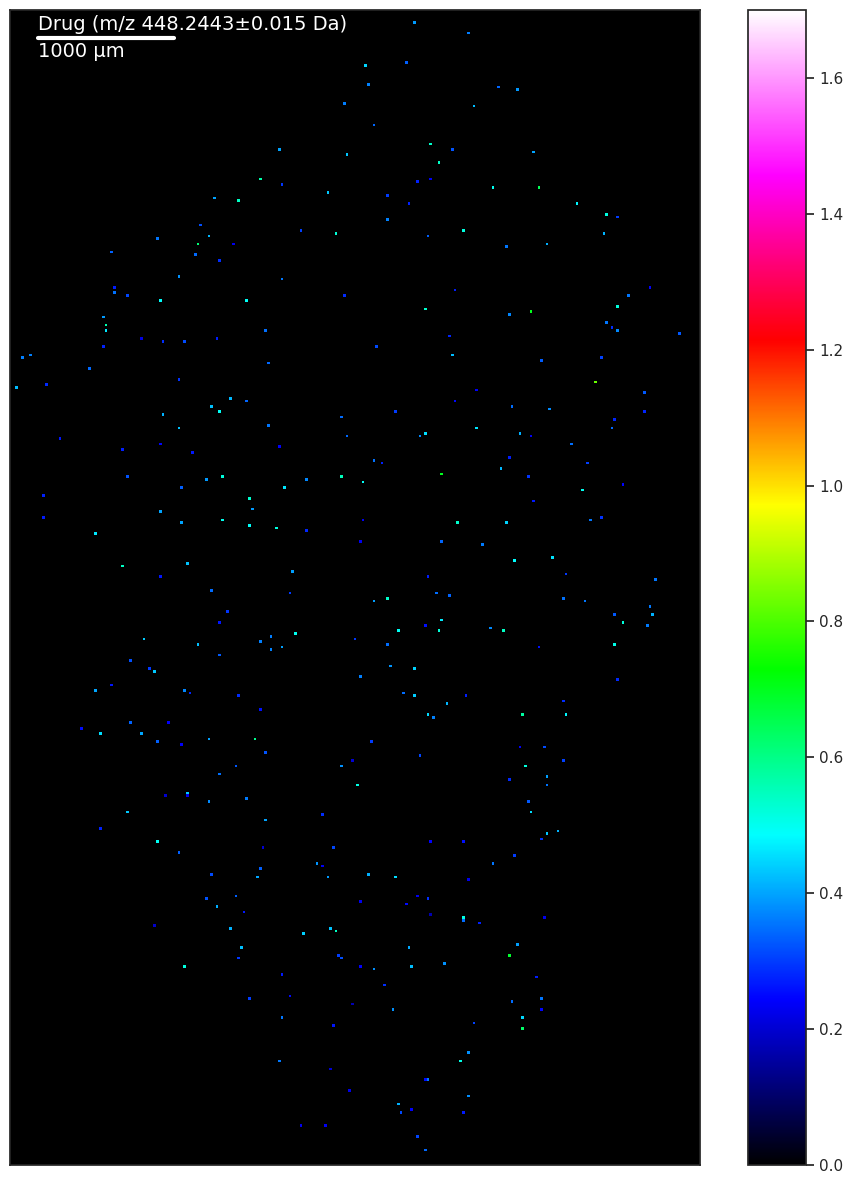

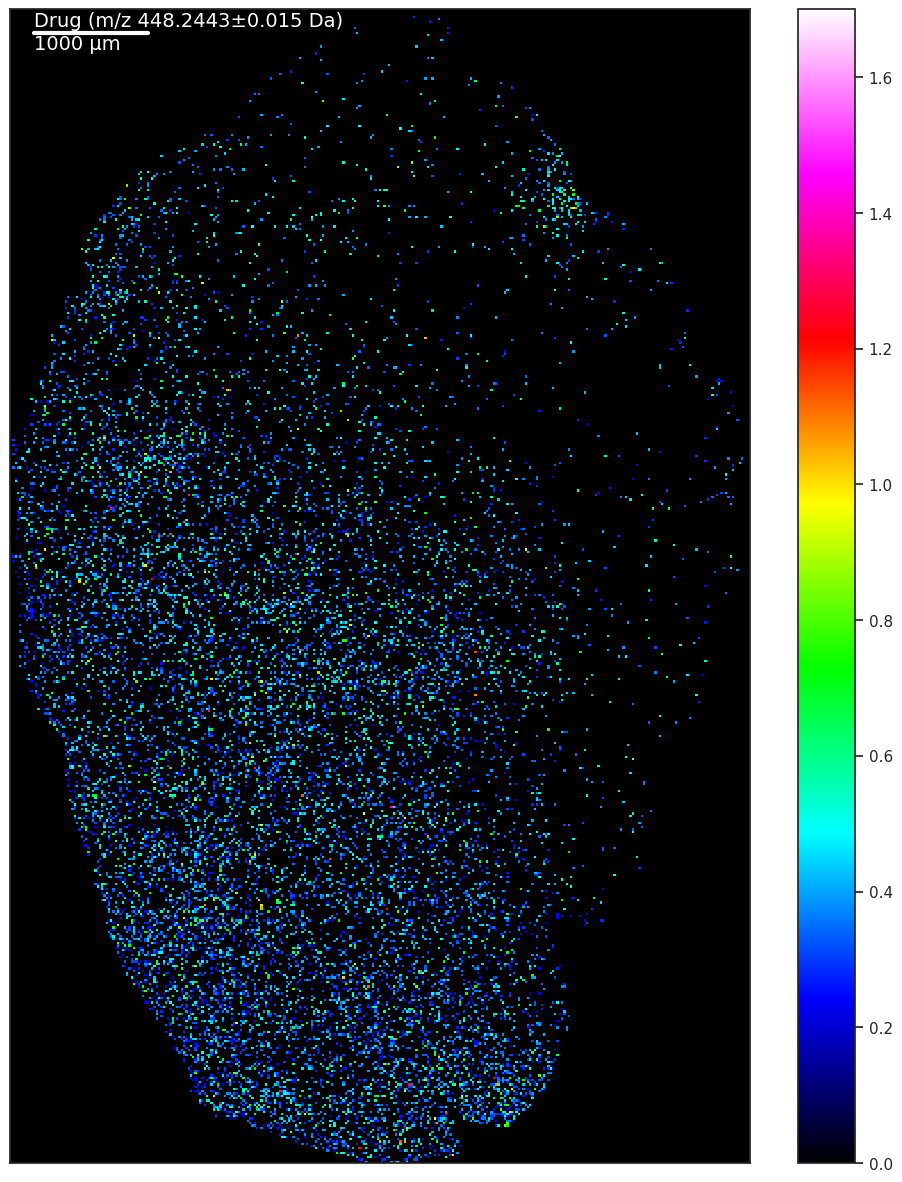

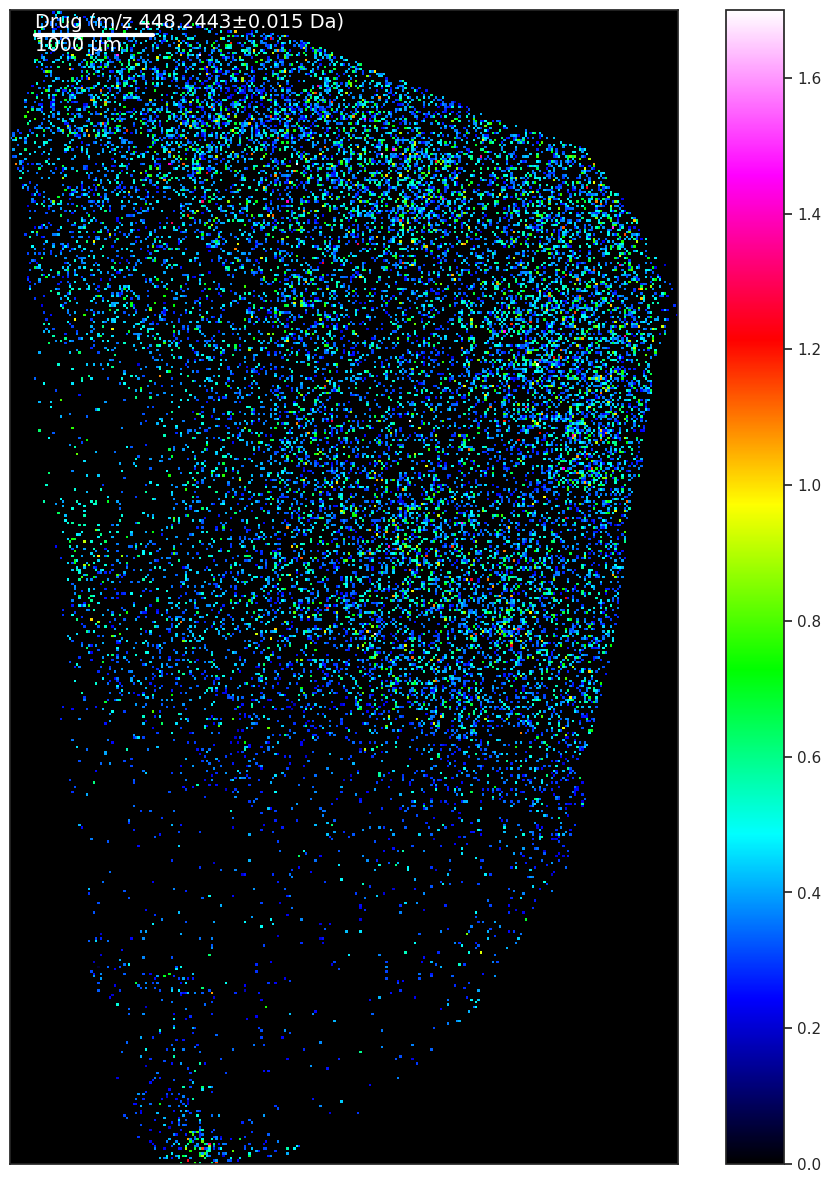

In [9]:
for sample in Sample_:
    # actually load the file
    I = m2.ImzMLReader(str(MALDI_RAW_PATH / f"dhb-tissue region {sample}.imzML"), 
                    normalization=m2.m2NormalizationRMS,
                    pooling=m2.m2PoolingMaximum
                    )
    # I.SetNormalization(m2.m2NormalizationTIC)
    # I.SetIntensityTransformation(m2.m2IntensityTransformationSquareRoot)
    ys_2 = I.GetMeanSpectrum()
    # get the ion image as array
    s = I.GetSpacing()
    drug = I.GetArray(448.2443, 0.015)
    fig,ax = showimg(drug[0], cmap=cm,vmin=0,vmax=1.7,
                    title='Drug (m/z 448.2443±0.015 Da)', spacing=s, subplot_pos=(1,1,1), size=(10,12))
    fig.tight_layout()
    fig.savefig(MALDI_PATH / f"drug_{sample}.pdf", dpi=300)

In [14]:
Sample = "Treated_1"
Sample_ = "treated 1"

In [4]:
Sample = "Ctrl_1"
Sample_ = "control 1"

In [30]:
# actually load the file
I = m2.ImzMLReader(str(MALDI_RAW_PATH / f"dhb-tissue region {Sample_}.imzML"), 
                   normalization=m2.m2NormalizationRMS,
                   pooling=m2.m2PoolingMaximum
                   )

[94.589] [imzML]: /home/uqxtan9/Q1851/Xiao/Working_project/MB/Xenium_Brain/MALDI_RAW/imzml_file/dhb-tissue region treated 1.imzML
	[pixel size (mm)]: 0.020000x0.020000x0.010000
	[image dimension]: 325x507x1
	[num spectra]: 116598
	[spec. type]: ProcessedCentroid
	[mass range]: 160.809851 to 2999.028857 with #1500 measurements
	[normalization]: RMS


In [31]:
mask = I.GetMaskArray()[0]

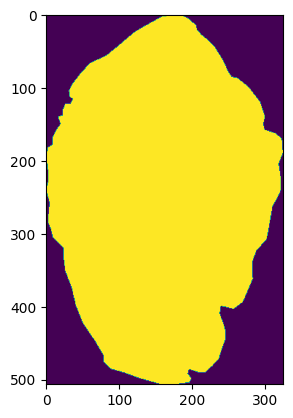

In [32]:
plt.imshow(mask)

In [33]:
# meta data is directly accessible
print("Spectrum Type:", I.GetSpectrumType())
print("Dimensions:", I.GetShape())
print("Pixel Spacing:", I.GetSpacing())
print("Pixels:", I.GetNumberOfSpectra())
print("Off-Pixels:", np.abs(np.product(I.GetShape()) - I.GetNumberOfSpectra()))
print("m/z Bins:", I.GetXAxisDepth())

Spectrum Type: ProcessedCentroid
Dimensions: [325 507   1]
Pixel Spacing: [0.02 0.02 0.01]
Pixels: 116598
Off-Pixels: 48177
m/z Bins: 1500


In [34]:
# export the settings 
print(I.GetParametersAsFormattedString())

# change some values 
I.SetBaselineCorrection(m2.m2BaselineCorrectionMedian)
print(I.GetParametersAsFormattedString())

(baseline-correction None)
(baseline-correction-hw 50)
(smoothing None)
(smoothing-hw 2)
(normalization RMS)
(pooling Maximum)
(transform None)

(baseline-correction Median)
(baseline-correction-hw 50)
(smoothing None)
(smoothing-hw 2)
(normalization RMS)
(pooling Maximum)
(transform None)



In [35]:
# get and print imzML related meta data
meta_data = I.GetMetaData()

pprint(meta_data)
# entries with leading IMS or MS tags are found in the imzML structure
# entries with 'm2aia.imzml.' are the actually internally used values 

{'(original imzML value) [IMS:1000042] max count of pixels x': '325',
 '(original imzML value) [IMS:1000043] max count of pixels y': '507',
 '(original imzML value) max count of pixels z': '1',
 '[IMS:1000031] processed': 'true',
 '[IMS:1000042] max count of pixels x': '325',
 '[IMS:1000043] max count of pixels y': '507',
 '[IMS:1000044] max dimension x': '6500',
 '[IMS:1000045] max dimension y': '10140',
 '[IMS:1000046] pixel size x': '0.02',
 '[IMS:1000047] pixel size y': '0.02',
 '[IMS:1000053] absolute position offset x': '0',
 '[IMS:1000054] absolute position offset y': '0',
 '[IMS:1000080] universally unique identifier': '772dda9f-b592-4746-a6e7-2a607573960e',
 '[IMS:1000090] ibd MD5': 'C81821CAD66395C34EF7507F91A813EE',
 '[IMS:1000101] intensities.external data': 'true',
 '[IMS:1000101] mzArray.external data': 'true',
 '[IMS:1000401] scanSettings0.top down': 'true',
 '[IMS:1000410] scanSettings0.meandering': 'true',
 '[IMS:1000480] scanSettings0.horizontal line scan': 'true',
 '

In [36]:
pprint([f for f in meta_data if 'processingMethod' in f])

['[MS:1000544] dataProcessing0.processingMethod (0).Conversion to mzML',
 '[MS:1000593] dataProcessing0.processingMethod (0).baseline reduction']


In [37]:
ys_1 = I.GetMeanSpectrum()
xs = I.GetXAxis()

I.SetIntensityTransformation(m2.m2IntensityTransformationSquareRoot)
I.Load()
ys_2 = I.GetMeanSpectrum()

I.SetSmoothing(m2.m2SmoothingGaussian,4)
I.Load()
ys_3 = I.GetMeanSpectrum()

I.SetSmoothing(m2.m2SmoothingGaussian, 50)
I.Load()
ys_4 = I.GetMeanSpectrum()

[104.406] [imzML]: /home/uqxtan9/Q1851/Xiao/Working_project/MB/Xenium_Brain/MALDI_RAW/imzml_file/dhb-tissue region treated 1.imzML
	[pixel size (mm)]: 0.020000x0.020000x0.010000
	[image dimension]: 325x507x1
	[num spectra]: 116598
	[spec. type]: ProcessedCentroid
	[mass range]: 160.809851 to 2999.028857 with #1500 measurements
	[baseline correction]: Median(50)
	[normalization]: RMS
	[processing]: SquareRoot
[114.193] [imzML]: /home/uqxtan9/Q1851/Xiao/Working_project/MB/Xenium_Brain/MALDI_RAW/imzml_file/dhb-tissue region treated 1.imzML
	[pixel size (mm)]: 0.020000x0.020000x0.010000
	[image dimension]: 325x507x1
	[num spectra]: 116598
	[spec. type]: ProcessedCentroid
	[mass range]: 160.809851 to 2999.028857 with #1500 measurements
	[baseline correction]: Median(50)
	[smoothing]: Gaussian(4)
	[normalization]: RMS
	[processing]: SquareRoot
[123.606] [imzML]: /home/uqxtan9/Q1851/Xiao/Working_project/MB/Xenium_Brain/MALDI_RAW/imzml_file/dhb-tissue region treated 1.imzML
	[pixel size (mm)]:

In [38]:
imz = 448.2443

Intensities 1500
Intensities in m/z range 31


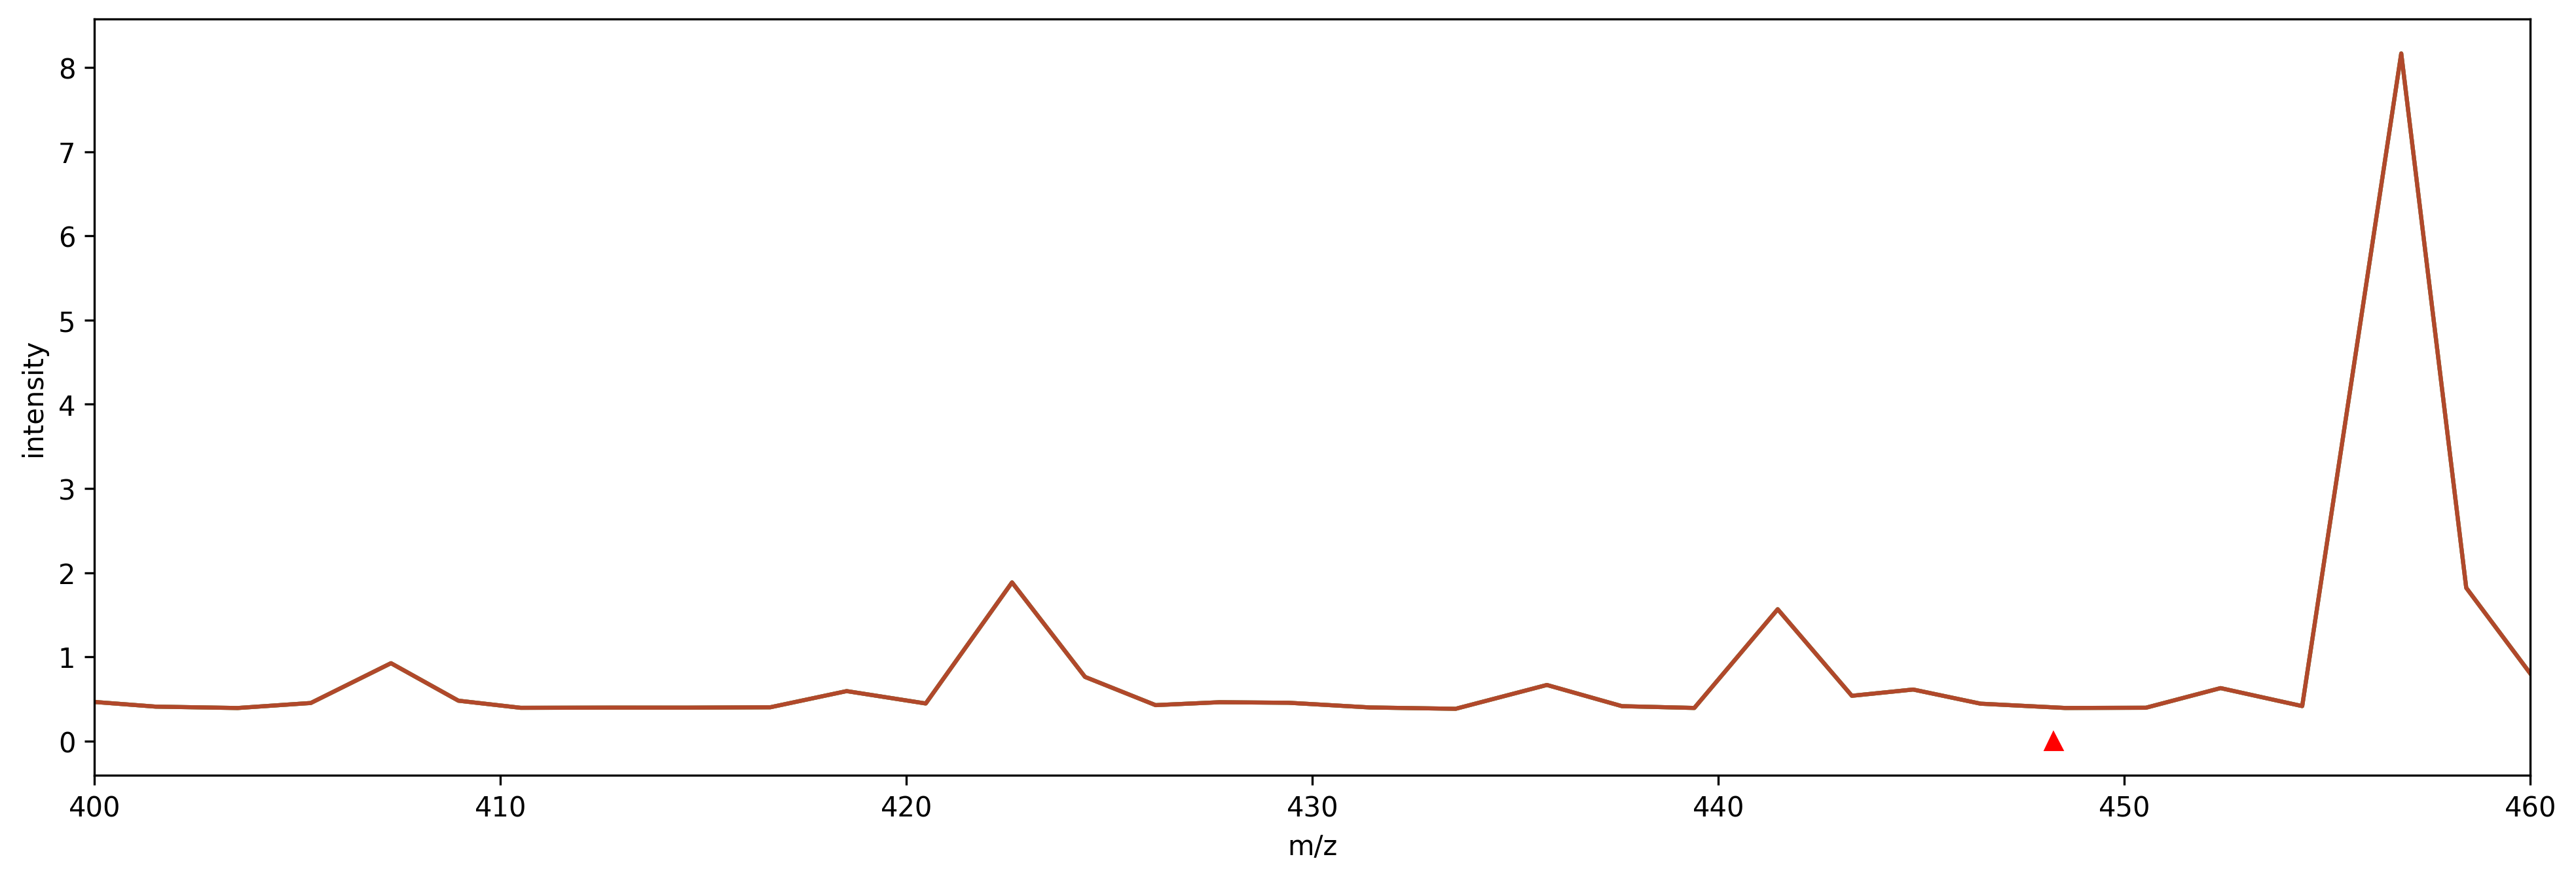

In [40]:
x_lim = [400,460]
fig, ax = plt.subplots(1,1, figsize=(16,5), dpi=300)
# plt.gca().set_aspect(3)

plt.xlim(x_lim)
# plt.ylim([-0.01,200])
# plt.ylim([-0.01,1])
# plt.ylim([60,75])
plt.xlabel('m/z')
plt.ylabel('intensity')
plt.plot(xs, ys_1, alpha=0.7)
plt.plot(xs, ys_2, alpha=0.7)
plt.plot(xs, ys_3, alpha=0.7)
plt.plot(xs, ys_4, alpha=0.7)
plt.plot(imz,0, 'r^')
# plt.legend(['TIC Normalization', ' + SR Transform', ' + Smoothing (hws 4)', 
            # ' + Smoothing (hws 50)'])
# plt.savefig('results/example_ii.png', dpi=350)

print(f'Intensities', I.GetXAxisDepth())
print(f'Intensities in m/z range {np.sum(xs >= x_lim[0]) - np.sum(xs > x_lim[1])}')

In [86]:
# actually load the file
I = m2.ImzMLReader(str(MALDI_RAW_PATH / f"dhb-tissue region {Sample_}.imzML"),
                   normalization=m2.m2NormalizationRMS)

[215.266] [imzML]: /home/uqxtan9/Q1851/Xiao/Working_project/MB/Xenium_Brain/MALDI_RAW/imzml_file/dhb-tissue region treated 2.imzML
	[pixel size (mm)]: 0.020000x0.020000x0.010000
	[image dimension]: 283x489x1
	[num spectra]: 101149
	[spec. type]: ProcessedCentroid
	[mass range]: 160.751642 to 2999.023485 with #1500 measurements
	[normalization]: RMS


In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

def showimg(image, cmap=None, 
            vmin=None, vmax=None,
            title=None, size=(10,10), spacing=None, fig=None, subplot_pos=(1,1,1)):
    sns.set_theme(style="ticks")
    
    if fig is None:
        fig = plt.figure(figsize = size) # create a 5 x 5 figure 
    
    ax = fig.add_subplot(subplot_pos[0],subplot_pos[1],subplot_pos[2])

    ax.tick_params(
        which='both',
        bottom=False,
        left=False,
        labelleft=False,
        labelbottom=False)
    x = [10,60]
    y = [10,10]

    if spacing is not None:
        ax.plot(x, y, color="white", linewidth=3)
        ax.text(x[0], y[0]+7, f"{int(spacing[0]*(x[1]-x[0])* 1000)} μm", color="white",size=14)
        
    if title:
        ax.text(x[0], y[0]-3, title, color="white", size=14)
        
    im = ax.imshow(image, interpolation='none', cmap=cmap, vmin=vmin, vmax=vmax)
    fig.colorbar(im)

    return fig, ax 

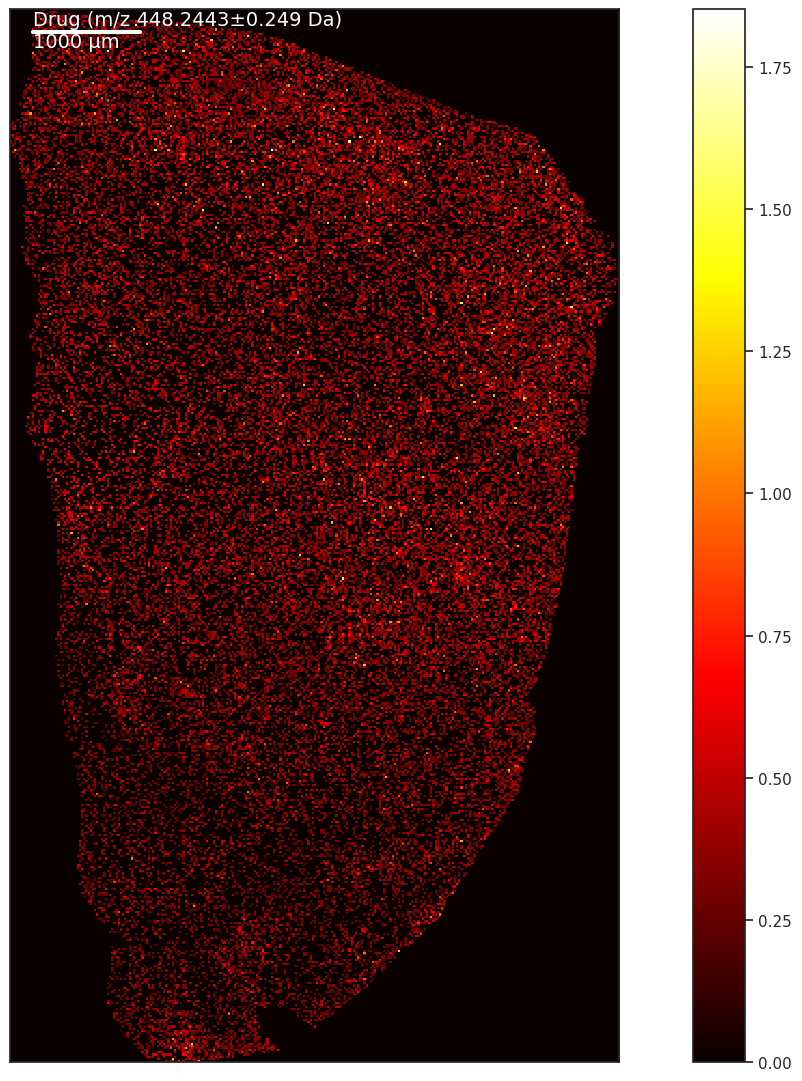

In [88]:
I.SetPooling(m2.m2PoolingMean)

# get the spacing for the size indicator
s = I.GetSpacing()

# Get ion images and convert it to 2D slices
drug = I.GetArray(448.2443, 0.25)


fig,ax = showimg(drug[0], cmap='hot', vmin=0,vmax=1,7,
                 title='Drug (m/z 448.2443±0.249 Da)', spacing=s, subplot_pos=(1,1,1), size=(15,11))
fig.tight_layout()

[144.588] [imzML]: /home/uqxtan9/Q1851/Xiao/Working_project/MB/Xenium_Brain/MALDI_RAW/imzml_file/dhb-tissue region treated 1.imzML
	[pixel size (mm)]: 0.020000x0.020000x0.010000
	[image dimension]: 325x507x1
	[num spectra]: 116598
	[spec. type]: ProcessedCentroid
	[mass range]: 160.809851 to 2999.028857 with #1500 measurements
	[normalization]: RMS


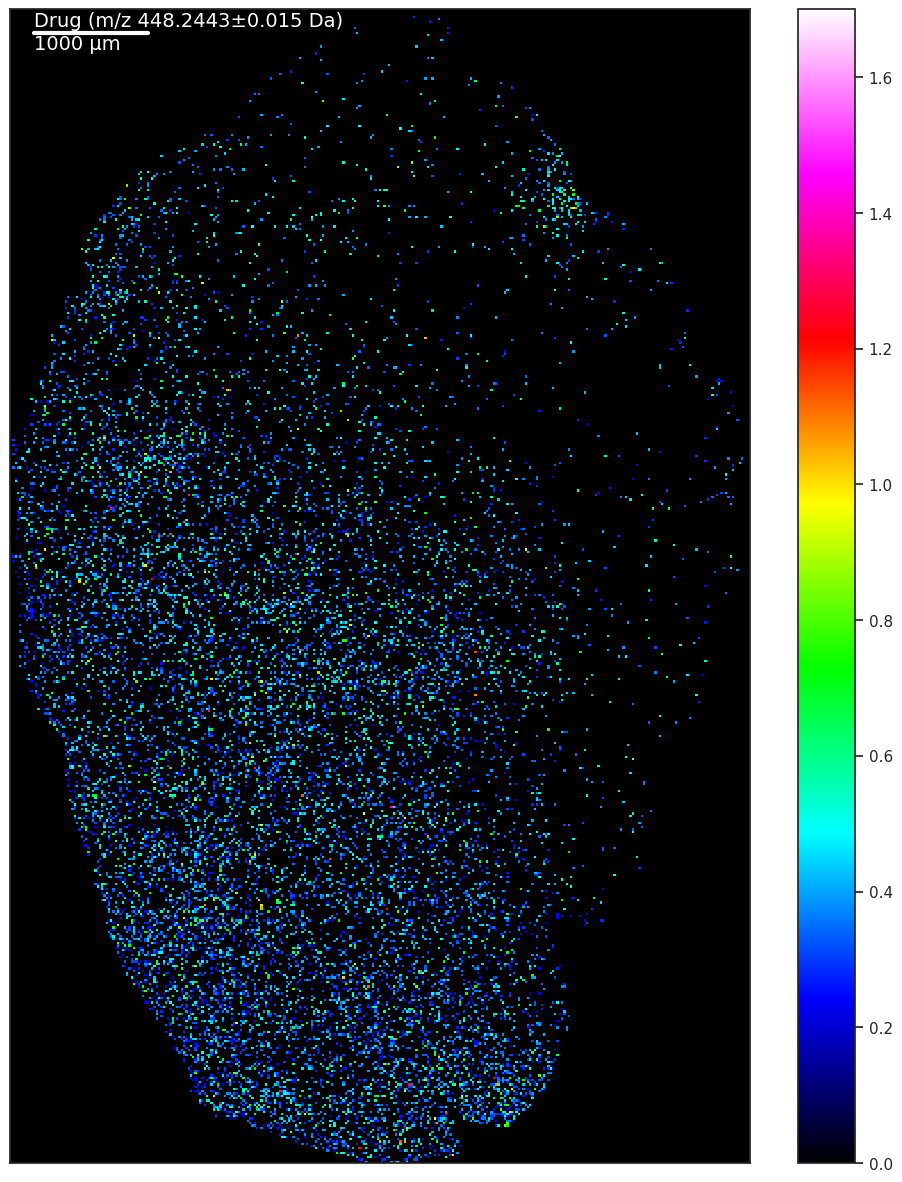

In [44]:
# actually load the file
I = m2.ImzMLReader(str(MALDI_RAW_PATH / f"dhb-tissue region treated 1.imzML"), 
                   normalization=m2.m2NormalizationRMS,
                   pooling=m2.m2PoolingMaximum
                   )
# I.SetNormalization(m2.m2NormalizationTIC)
# I.SetIntensityTransformation(m2.m2IntensityTransformationSquareRoot)
ys_2 = I.GetMeanSpectrum()
# get the ion image as array
s = I.GetSpacing()
drug = I.GetArray(448.2443, 0.015)
fig,ax = showimg(drug[0], cmap=cm,vmin=0,vmax=1.7,
                 title='Drug (m/z 448.2443±0.015 Da)', spacing=s, subplot_pos=(1,1,1), size=(10,12))
fig.tight_layout()

[64.757] [imzML]: /home/uqxtan9/Q1851/Xiao/Working_project/MB/Xenium_Brain/MALDI_RAW/imzml_file/dhb-tissue region control 1.imzML
	[pixel size (mm)]: 0.020000x0.020000x0.010000
	[image dimension]: 310x356x1
	[num spectra]: 84027
	[spec. type]: ProcessedCentroid
	[mass range]: 160.713978 to 2999.027599 with #1500 measurements
	[normalization]: RMS


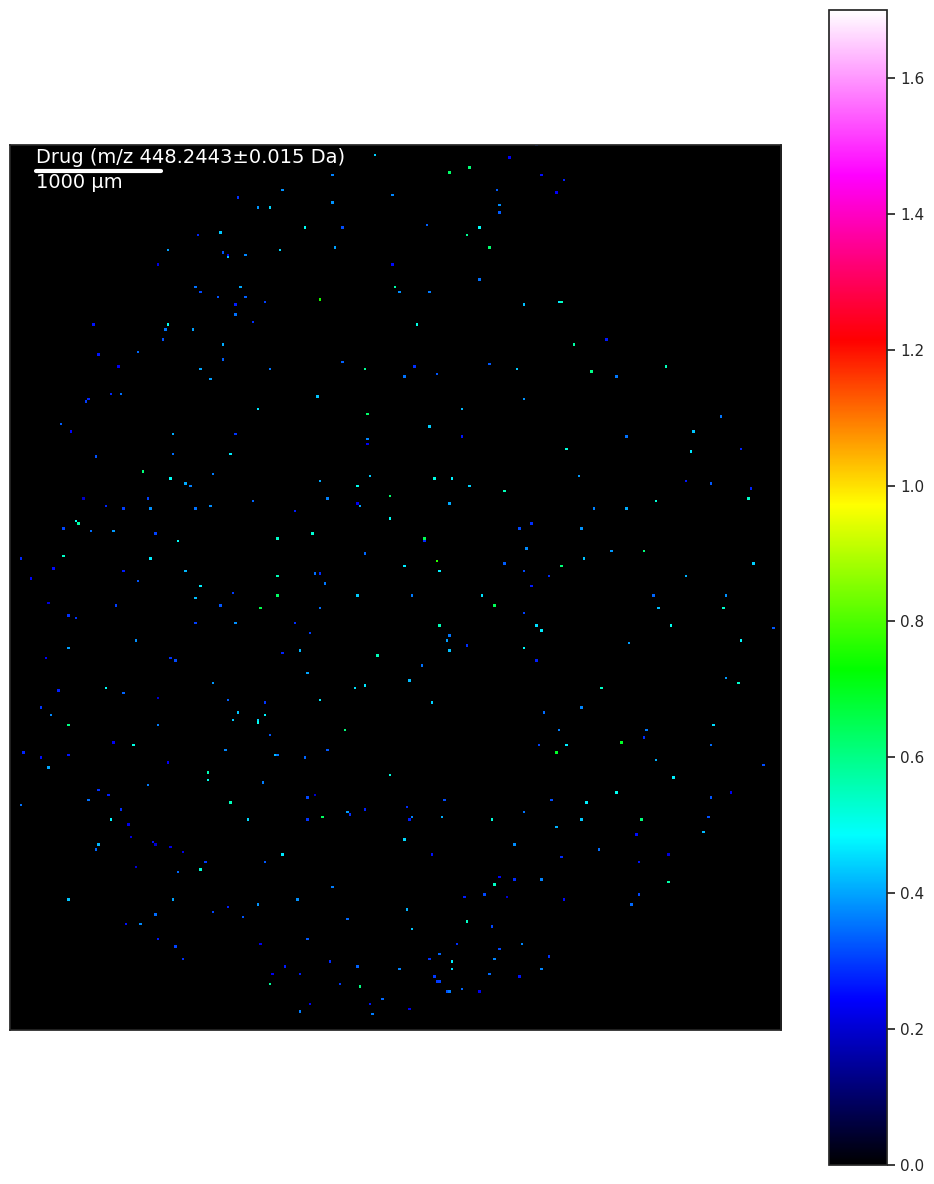

In [27]:
# actually load the file
I = m2.ImzMLReader(str(MALDI_RAW_PATH / f"dhb-tissue region control 1.imzML"), 
                   normalization=m2.m2NormalizationRMS,
                   pooling=m2.m2PoolingMaximum
                   )
# I.SetNormalization(m2.m2NormalizationTIC)
# I.SetIntensityTransformation(m2.m2IntensityTransformationSquareRoot)
ys_2 = I.GetMeanSpectrum()
# get the ion image as array
s = I.GetSpacing()
drug = I.GetArray(448.2443, 0.015)
fig,ax = showimg(drug[0], cmap=cm,vmin=0,vmax=1.7,
                 title='Drug (m/z 448.2443±0.015 Da)', spacing=s, subplot_pos=(1,1,1), size=(10,12))
fig.tight_layout()

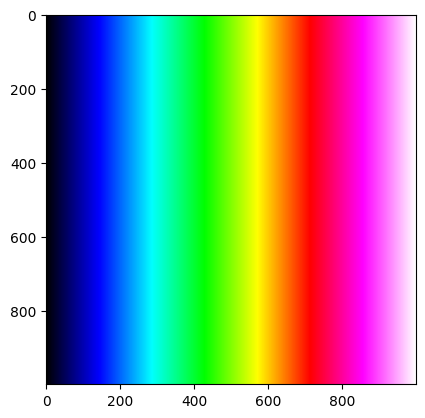

In [43]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

colors = [(0, 0, 0), (0, 0, 1), (0, 1, 1), (0, 1, 0),(1, 1, 0), (1, 0, 0),(1, 0, 1),(1, 1, 1)] 
cm = LinearSegmentedColormap.from_list(
        "Custom", colors, N=1000)
mat = np.indices((1000,1000))[1]
plt.imshow(mat, cmap=cm)
plt.show()

In [37]:
import matplotlib


matplotlib.colors.Colormap

In [47]:
drug.shape

(1, 507, 325)

In [16]:
gene_list = pd.read_csv("./Xenium_hBrain_v1_metadata.csv")

In [19]:
for i in gene_list["Genes"]:
    print(i)

ABCC9
ADAMTS12
ADAMTS16
ADAMTS3
ADRA1A
ADRA1B
AIF1
ALK
ANGPT1
ANK1
ANKRD18A
ANO3
ANXA1
APOE
APP
AQP4
ARHGAP24
ATP2C2
B4GALNT1
BCAN
BRINP3
BTBD11
C1QL3
C1orf162
CALCRL
CAPG
CAPN3
CAV1
CCK
CCL4
CCL5
CCNA1
CCNB2
CD14
CD163
CD2
CD36
CD3G
CD4
CD48
CD52
CD68
CD83
CD86
CDH1
CDH12
CDH4
CDH6
CDK1
CEMIP
CEMIP2
CENPF
CHODL
CLDN11
CNDP1
CNTN2
CNTNAP3B
COL12A1
COL25A1
CORO1A
CRHBP
CRYM
CSPG4
CTNNA3
CTSH
CTSS
CUX2
CX3CR1
CXCL14
CXCR4
CYTIP
DCN
DDR2
DNER
EFHD1
EGFR
ELOVL2
ERBB3
ERMN
EYA4
FASLG
FBLN1
FCER1G
FCGR1A
FCGR3A
FGFR2
FGFR3
FILIP1
FLT1
FSTL4
GAD1
GAD2
GAS2L3
GJA1
GNLY
GPNMB
GPR183
GPR34
GZMA
HES1
HHATL
HILPDA
HLA-DMB
HLA-DQA1
HS3ST2
HS3ST4
HTR2A
HTR2C
IDH1
IDH2
IDO1
IFITM3
IGFBP3
IGFBP4
IGFBP5
IL7R
ITGA8
ITGAM
ITGAX
ITGB2
KCNH5
KIT
KLF2
KLF4
KLK6
KLRB1
LAMA2
LAMP5
LHX6
LOX
LRRK1
LRRK2
LY86
LYPD6
LYPD6B
LYVE1
MAG
MAL
MCTP2
MEIS2
MEPE
MGST1
MKI67
MOBP
MOG
MS4A6A
MYO16
MYO5B
MYRF
NCSTN
NDST4
NES
NKG7
NNAT
NOTCH1
NPFFR2
NPNT
NPY1R
NR2F2
NR4A2
NRP1
NTNG1
NTNG2
NWD2
NXPH2
OLIG1
OLIG2
OPALIN
OTOGL
P